In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
data = load_diabetes()

In [16]:
X = data["data"]
y = data["target"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
rr = Ridge(alpha=0.1, solver="cholesky")
rr.fit(X_train, y_train)
y_pred_rr = rr.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_rr))
print("R2 Score:", (r2_score(y_test, y_pred_rr))*100)
print(f"coefficients: {rr.coef_}")
print(f"intercept: {rr.intercept_}")

Mean Squared Error: 2856.486887670654
R2 Score: 46.085219464119255
coefficients: [  42.85566976 -205.49431899  505.08903304  317.0932049  -108.50026183
  -86.23673333 -190.36318008  151.70708637  392.28931896   79.9081772 ]
intercept: 151.4585745667961


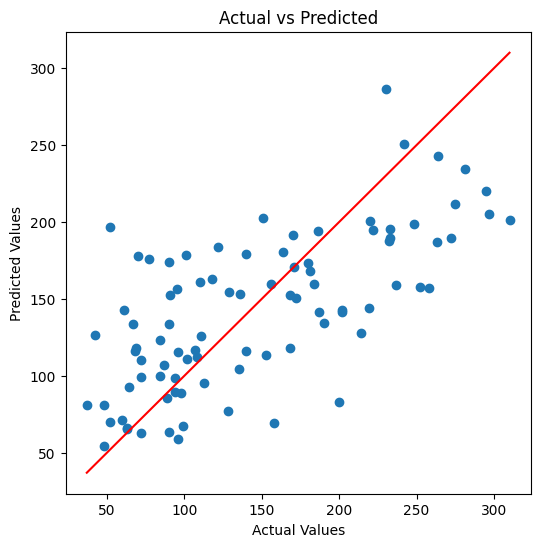

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", (r2_score(y_test, y_pred_lr))*100)
print(f"coefficients: {lr.coef_}")
print(f"intercept: {lr.intercept_}")

Mean Squared Error: 2900.193628493482
R2 Score: 45.260276297191936
coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
intercept: 151.34560453985995


In [ ]:
class RidgeRegularization:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        self.betas = None

    def fit(self, X_train, y_train):

        # Add column of ones
        X_train = np.insert(X_train, 0, 1, axis=1)

        # Identity matrix
        identity_matrix = np.eye(X_train.shape[1])

        # Don't regularize intercept
        identity_matrix[0, 0] = 0

        # Ridge formula
        self.betas = np.linalg.inv(
            X_train.T @ X_train + self.alpha * identity_matrix
        ) @ (X_train.T @ y_train)

        # Separate intercept and coefficients
        self.intercept_ = self.betas[0]
        self.coef_ = self.betas[1:]

    def predict(self, X_test):

        # DON'T insert column of ones here
        return X_test @ self.coef_ + self.intercept_

    def score(self, X_test, y_test):

        y_pred = self.predict(X_test)

        return r2_score(y_test, y_pred)*100


In [28]:
my_ridge_regression_model = RidgeRegularization(alpha=0.1)

my_ridge_regression_model.fit(X_train, y_train)

y_pred_my_model = my_ridge_regression_model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_my_model))
print("R2 Score:", my_ridge_regression_model.score(X_test, y_test))
print(f"coefficients: {my_ridge_regression_model.coef_}")
print(f"intercept: {my_ridge_regression_model.intercept_}")

Mean Squared Error: 2856.4868876706546
R2 Score: 46.08521946411924
coefficients: [  42.85566976 -205.49431899  505.08903304  317.0932049  -108.50026183
  -86.23673333 -190.36318008  151.70708637  392.28931896   79.9081772 ]
intercept: 151.45857456679607
